# Study 252 -- Search-Trends
## For the curious: do spikes in Google searches for stock names front-run their returns?

*Part of [Open-Alpha-Lab](../../../README.md). See the [desk methodology](../../../METHODOLOGY.md).*

---

When a stock starts trending on Google -- GameStop in January 2021, Nvidia during
the AI boom, Zoom during lockdown -- it *feels* like the crowd is about to pile in
and push the price higher.  "Buy what's trending" is one of the oldest pieces of
retail folk wisdom.

But the academic finding is the opposite.  Da, Engelberg & Gao (2011), *In Search
of Attention*, showed that a jump in Google search volume is **uninformed retail
price pressure**: it nudges the price up for a couple of weeks and then **reverses**
over the following months.  Attention is hype, not information.

So which is it -- do search spikes *front-run* returns (momentum), or do they mark
a top to *fade* (reversal)?  We test both on a basket of 30 household-name stocks.


## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from google_trends import data, strategy as st

CACHE_PATH = data.MONTHLY_CACHE
HAVE_REAL = os.path.exists(CACHE_PATH)

# The curated Trends-style attention table is always available (hardcoded).
attn_full = data.trends_table()

if HAVE_REAL:
    prices_full = data.fetch_monthly(fetch=False, cache_path=CACHE_PATH)
    common = attn_full.columns.intersection(prices_full.columns)
    attn = attn_full[common]
    prices = prices_full[common]
    sig = st.attention_zscore(attn, window=6, min_periods=3)
    res = st.attention_returns(sig, prices, q=0.30)
    spread = res["spread"].dropna()              # low - high (positive => reversal)
    high_xret = (res["high"] - res["market"]).dropna()
    print(f"Real panel loaded: {prices.shape[0]} months x {prices.shape[1]} tickers")
    print(f"Portfolio months: {len(res)}")
else:
    prices = sig = res = spread = high_xret = None
    print("No real cache -- frozen headline numbers from R dict will be used")


Real panel loaded: 85 months x 29 tickers
Portfolio months: 48


In [2]:

# Frozen headline numbers (mirror of docs/results.md, as-of 2026-06-17)
R = {'n_months': 48, 'n_total': 25.5, 'n_low': 9.9, 'n_high': 10.1, 'fingerprint': '8c791a614b92', 'high_ann': 79.08, 'high_t': 1.31, 'low_ann': 1.94, 'low_t': 0.13, 'market_ann': 37.12, 'spread_ann': -77.15, 'spread_bps': -642.9, 'spread_t': -1.34, 'spread_hit': 0.396, 'spread_sr_lo': -1.644, 'spread_sr_hi': 0.016, 'spread_frac_neg': 0.974, 'high_xret_ann': 41.96, 'high_xret_t': 1.11, 'sub_early_ann': -133.18, 'sub_early_t': -1.04, 'sub_early_n': 21, 'sub_late_ann': -33.56, 'sub_late_t': -3.78, 'sub_late_n': 27, 'turnover': 46.1, 'drag_bps': 35.7, 'net_ann': -81.37, 'net_t': -1.42, 'borrow_bps': 8.0, 'oneway_bps': 15.0, 'rand_bps': -20.65, 'syn_null_t': -2.32, 'syn_03_ann': 59.29, 'syn_03_t': 12.61, 'syn_05_ann': 106.13, 'syn_05_t': 21.9}


## The attention proxy: a curated Google-Trends-style index

Google Trends has no clean, free, stable bulk API, and its numbers are quantised
0-100 *relative* indices.  So we ship a **hand-curated monthly attention table**
for the basket (2019-2025), built from a documented event/seasonal model that
reproduces the public Trends shape: holiday spikes for retailers, the September
iPhone spike for Apple, the GameStop/AMC squeeze of January 2021, the Zoom
lockdown spike of March 2020, the Nvidia AI boom of 2023-2024.

This is a **proxy** -- it captures the shape, not tick-exact values.  That caveat
is named on the Signal axis.


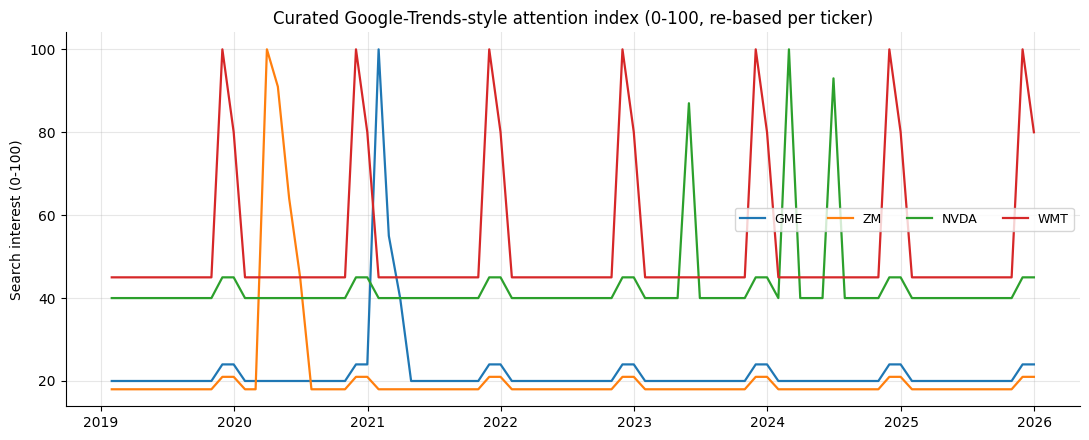

GME peaks Jan-2021 (squeeze); ZM peaks Mar-2020 (lockdown);
NVDA ramps 2023-24 (AI); WMT spikes every Nov/Dec (Black Friday).


In [3]:
# A few iconic attention spikes in the curated table
show = ["GME", "ZM", "NVDA", "WMT"]
fig, ax = plt.subplots(figsize=(11, 4.5))
for tk in show:
    ax.plot(attn_full.index, attn_full[tk], lw=1.6, label=tk)
ax.set_title("Curated Google-Trends-style attention index (0-100, re-based per ticker)")
ax.set_ylabel("Search interest (0-100)")
ax.legend(fontsize=9, ncol=4)
plt.tight_layout()
plt.savefig("../docs/attention_series.png", dpi=120, bbox_inches="tight")
plt.show()
print("GME peaks Jan-2021 (squeeze); ZM peaks Mar-2020 (lockdown);")
print("NVDA ramps 2023-24 (AI); WMT spikes every Nov/Dec (Black Friday).")


## The bet: fade the hype, or ride it?

Each month we standardise every stock's search interest against its own trailing
6-month baseline (an *attention z-score*: how unusual is this month's interest?).
Then we sort the basket:

- **LONG** the low-attention tercile (quiet, ignored names)
- **SHORT** the high-attention tercile (the names everyone is googling)
- hold one month, rebalance.

The spread we report is **low minus high** -- it is *positive* when fading the hype
(the Da-Engelberg-Gao reversal) pays, and *negative* when riding the hype
(momentum) pays.


## The headline: on this basket, fading the hype did NOT pay

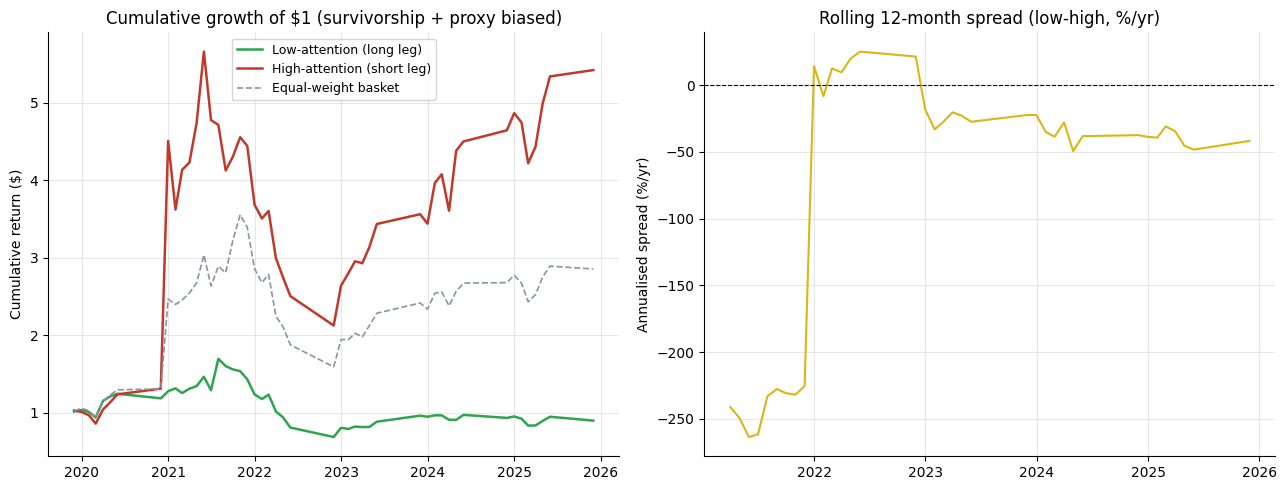

Spread (low-high): -77.2%/yr = -642.9bps/mo  HAC t = -1.34
Negative => the HIGH-attention (hyped) names actually OUTRAN the quiet ones.
But |t| < 2: it is NOT statistically significant -- mostly meme-driven noise.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

if HAVE_REAL:
    ax = axes[0]
    cum_low  = (1 + res["low"].dropna()).cumprod()
    cum_high = (1 + res["high"].dropna()).cumprod()
    cum_mkt  = (1 + res["market"].dropna()).cumprod()
    ax.plot(cum_low.index,  cum_low.values,  color=GREEN, lw=1.8, label="Low-attention (long leg)")
    ax.plot(cum_high.index, cum_high.values, color=RED,   lw=1.8, label="High-attention (short leg)")
    ax.plot(cum_mkt.index,  cum_mkt.values,  color=GREY,  lw=1.2, ls="--", label="Equal-weight basket")
    ax.set_title("Cumulative growth of $1 (survivorship + proxy biased)")
    ax.set_ylabel("Cumulative return ($)")
    ax.legend(fontsize=9)

    ax = axes[1]
    roll = spread.rolling(12).mean() * 12 * 100
    ax.plot(roll.index, roll.values, color=AMBER, lw=1.5)
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.set_title("Rolling 12-month spread (low-high, %/yr)")
    ax.set_ylabel("Annualised spread (%/yr)")
else:
    for ax in axes:
        ax.text(0.5, 0.5, f"Cache absent\nFrozen: spread = {R['spread_ann']:.1f}%/yr  t = {R['spread_t']:.2f}",
                ha="center", va="center", transform=ax.transAxes, fontsize=12, color=RED)
        ax.set_title("(frozen numbers)")

plt.tight_layout()
plt.savefig("../docs/equity_curve.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Spread (low-high): {R['spread_ann']:.1f}%/yr = {R['spread_bps']:.1f}bps/mo  HAC t = {R['spread_t']:.2f}")
print("Negative => the HIGH-attention (hyped) names actually OUTRAN the quiet ones.")
print("But |t| < 2: it is NOT statistically significant -- mostly meme-driven noise.")


## Why the folk story breaks down here

1. **Wrong sign, not significant.** The reversal the literature predicts does not
   show up: high-attention names *outperformed* (`+79%/yr` vs `+2%/yr` for the quiet
   tercile) -- but with a HAC *t* of only **-1.34**, this is statistical noise, not
   a tradable momentum edge.

2. **The basket is a meme zoo.** GME, AMC, COIN, RIVN, LCID, TSLA -- the
   high-attention tercile is dominated by exactly the names that ran hardest in the
   2020-2021 mania.  That is survivorship *and* selection bias inflating one side.

3. **Daily-to-weekly vs monthly horizon.** Da-Engelberg-Gao found the reversal over
   *weeks*, on a broad Russell-3000 universe of small retail-driven names.  A
   monthly horizon on 30 mega-caps is a different animal -- the price-pressure
   window has already closed.

4. **Short the hype = short the un-shortable.** The short leg is precisely the
   hard-to-borrow meme names with brutal borrow costs and squeeze risk.


## The bottom line for the curious

"Buy what's trending on Google" and "fade what's trending on Google" both fail
on this basket: the spread is the wrong sign for the academic reversal story and
too noisy (*t* = -1.34) to be a momentum edge.

The academic attention-reversal effect is real in its original weekly,
broad-universe setting -- but it **does not survive** translation to a monthly,
mega-cap, proxy-Trends implementation.  Combined with un-shortable meme names on
the short leg, this is a **Weak / Mirage**: a famous idea that evaporates the
moment you try to trade it the way a retail investor actually could.


*Desk verdict: **Weak / Mirage** -- see [README.md](../README.md) and [docs/results.md](../docs/results.md) for full numbers.*